<a href="https://colab.research.google.com/github/joysujeeth1761/Adversarial_ML/blob/main/OPTIMIZATION_BASED_ATTACK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**C&W methods**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim#importing optimizer
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
#device confo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [ ]:
#loading MNIST dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

print("MNIST Dataset Loaded")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.45MB/s]

MNIST Dataset Loaded


In [ ]:
#building simple CNN model
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 5 * 5)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x


In [ ]:
model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)




In [ ]:
#training cnn model with MNIST dataset
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

print("Training Completed")


Epoch 1, Loss: 165.6367
Epoch 2, Loss: 50.9446
Epoch 3, Loss: 36.5568
Training Completed


In [ ]:
#testing model accuracy
def test_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Normal Accuracy: {accuracy:.2f}%")

test_accuracy(model, test_loader)

Normal Accuracy: 98.56%


In [ ]:
#c&w attack function

def cw_attack(model,
              image,
              label,
              c=1,
              steps=100,
              lr=0.01):

    model.eval()

    # Initialize perturbation
    delta = torch.zeros_like(
        image,
        requires_grad=True
    )

    optimizer = optim.Adam(
        [delta],
        lr=lr
    )

    # Target class
    target_label = (label + 1) % 10

    for step in range(steps):

        # Create adversarial image
        adv_image = torch.clamp(
            image + delta,
            0,
            1
        )

        output = model(adv_image)

        # Targeted attack loss
        target_loss = -output[0, target_label]

        # L2 distortion loss
        l2_loss = torch.norm(
            delta.view(-1),
            p=2
        )

        # Total loss
        loss = l2_loss + c * target_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    adv_image = torch.clamp(
        image + delta,
        0,
        1
    )

    return adv_image.detach()



In [ ]:
#visualiton fucntion for c&w
def show_image(img, title):

    img = img.squeeze().cpu().detach().numpy()

    plt.imshow(img, cmap='gray')

    plt.title(title)

    plt.axis('off')

    plt.show()


In [ ]:
#genration of adversial image
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = cw_attack(
    model,
    images,
    labels,
    c=1,
    steps=100,
    lr=0.01
)


In [ ]:
#predictions

output1 = model(images)
pred1 = output1.argmax(dim=1)

output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

Original Prediction: 7
Adversarial Prediction: 8


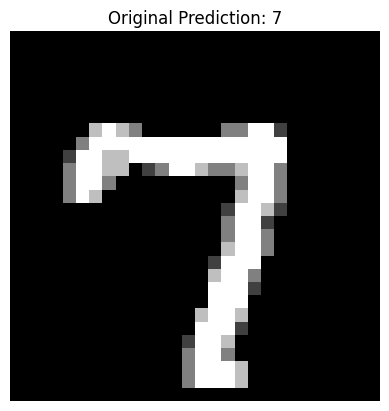

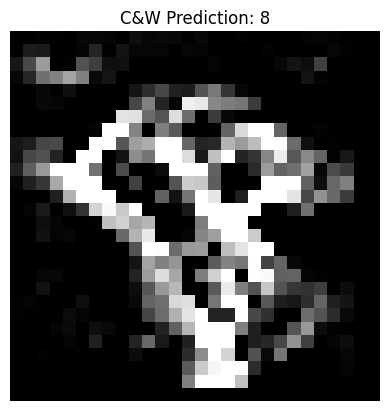

In [ ]:
show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"C&W Prediction: {pred2.item()}"
)

**EAD(ELASTIC NET ATTACK )**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


In [3]:
#loading MNIST dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

print("MNIST Dataset Loaded")

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 405kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.77MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.79MB/s]

MNIST Dataset Loaded


In [4]:
# building CNN model
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 5 * 5)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x


In [5]:
model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [6]:
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")




Epoch 1, Loss: 169.1248
Epoch 2, Loss: 46.9503
Epoch 3, Loss: 32.6053
Training Completed


In [7]:
# testing Accuracy
def test_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Normal Accuracy: {accuracy:.2f}%")

test_accuracy(model, test_loader)


Normal Accuracy: 98.90%


In [8]:
#EAD attack function
def ead_attack(model,
               image,
               label,
               c=1,
               beta=0.01,
               steps=100,
               lr=0.01):

    model.eval()

    # Initialize perturbation
    delta = torch.zeros_like(
        image,
        requires_grad=True
    )

    optimizer = optim.Adam(
        [delta],
        lr=lr
    )

    # Target label
    target_label = (label + 1) % 10

    for step in range(steps):

        adv_image = torch.clamp(
            image + delta,
            0,
            1
        )

        output = model(adv_image)

        # Targeted attack loss
        target_loss = -output[0, target_label]

        # L1 loss
        l1_loss = torch.norm(
            delta.view(-1),
            p=1
        )

        # L2 loss
        l2_loss = torch.norm(
            delta.view(-1),
            p=2
        )

        # Total Elastic-Net loss
        loss = (
            c * target_loss
            + beta * l1_loss
            + l2_loss
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    adv_image = torch.clamp(
        image + delta,
        0,
        1
    )

    return adv_image.detach()



In [10]:
#visualization model
def show_image(img, title):

    img = img.squeeze().cpu().detach().numpy()

    plt.imshow(img, cmap='gray')

    plt.title(title)

    plt.axis('off')

    plt.show()

In [11]:
#generation of adversial example
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = ead_attack(
    model,
    images,
    labels,
    c=1,
    beta=0.01,
    steps=100,
    lr=0.01
)

Original Prediction: 1
Adversarial Prediction: 2


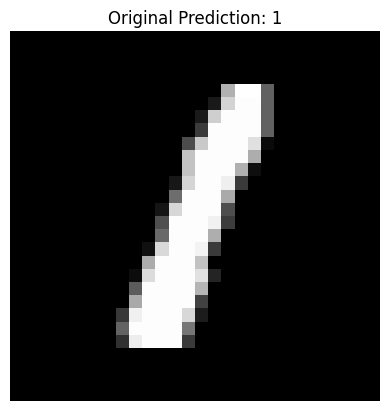

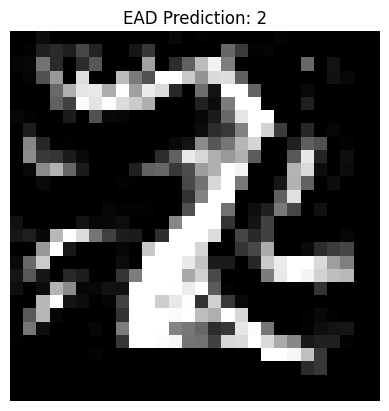

In [13]:
#PREDICTIONS

output1 = model(images)
pred1 = output1.argmax(dim=1)

output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"EAD Prediction: {pred2.item()}"
)
